# GMFD Analysis
### July 7, 2026

# Initialization

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv, find_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import math

import analysis_utils

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

In [3]:
_polygons = (
    gpd.read_parquet(IMPACT_REGION_POLYGONS)
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

socioeconomics =  xr.open_zarr(SOCIOECONOMICS_URI)
socioeconomics = socioeconomics.sel(year = 2026)[['pop0to4', 'pop5to64', 'pop65plus', 'pop']]

In [4]:
# IR Climate Data
forecast_gmfd = xr.open_zarr(os.path.join(DATA_DIR, "daily_forecast_GMFD_tas.zarr"))
reanlysis_gmfd = xr.open_zarr(os.path.join(DATA_DIR, "daily_reanalysis_GMFD_tas.zarr"))
# Grid Glimate Data
#forecast_gmfd_grid = xr.open_zarr('/home/emily_zuetell/projects/poreallas/scripts/data/forecast_ensemble_bias_adjusted_to_GMFD.zarr')
#reanalysis_gmfd_grid = xr.open_zarr('/home/emily_zuetell/projects/poreallas/scripts/data/reanalysis_bias_adjusted_to_GMFD.zarr')
# Old (No GMFD) Forecast
forecast_og = xr.open_zarr('/home/emily_zuetell/projects/poreallas/scripts/data/tas_forecast.zarr')

In [5]:
#Effects
effect_gmfd = xr.open_datatree(os.path.join(DATA_DIR,"v20260702/effects_net_hot_cold_gmfd_biasadjusted.zarr"), consolidated = False)
effect_og = xr.open_datatree(os.path.join(DATA_DIR,"v20260702/effects_net_hot_cold.zarr"), consolidated = False)

_max_year = effect_gmfd["/baseline"]["time"].max().dt.year.item()
# Subtracting 9 even though we want 10 year baseline because the time slice is an inclusive range.
_min_year = _max_year - 29
baseline_period = slice(str(_min_year), str(_max_year))

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [8]:
def compute_stats(da, polygon = False):
    mean = da.mean(dim="number")
    p10 = da.quantile(0.10, dim="number")
    p90 = da.quantile(0.90, dim="number")
    prange = p90 - p10

    ds_out = xr.Dataset({
        "mean": mean,
        "p10": p10.drop_vars("quantile"),
        "p90": p90.drop_vars("quantile"),
        "range": prange.drop_vars("quantile", errors="ignore"),
    })
    if polygon:
        _polygons_num = _polygons.merge(ds_out
            .to_dataframe()
            .reset_index(),
            on="region",)
        return _polygons_num
    return ds_out

## Hot_Only vs Cold_Only

In [9]:
hotonly = effect_gmfd['/forecast_hotonly']['effect']
coldonly = effect_gmfd['/forecast_coldonly']['effect']
total = effect_gmfd['/forecast']['effect']
sum_hot_cold = hotonly + coldonly
diff = total - sum_hot_cold

diff = diff.sel(age_cohort='age65plus').sum(dim='number')
_polygons_hot_cold = _polygons.merge(
    diff.groupby("time.month").mean().to_dataframe().reset_index(),
    on="region",
)


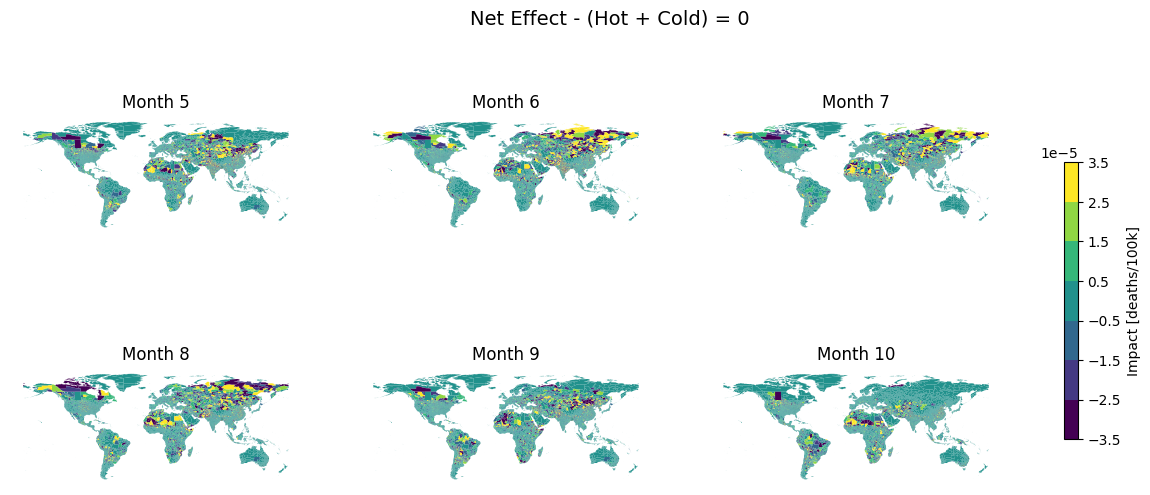

In [10]:
gdf = _polygons_hot_cold
col = 'effect'

fig = analysis_utils.plot_monthly(
    gdf,
    col=col,
    rate=True,
    sup_title="Net Effect - (Hot + Cold) = 0",
    save_title='hot_cold_net_effect.png',
    cm='viridis',
)

## Impact Percentiles

In [11]:
#Differences with old (not GMFD data) (hist with response curve)
impact_gmfd = analysis_utils.compute_impact(effect_gmfd, socioeconomics, ensemble = True, baseline_period=baseline_period, hotonly = False, rate = True, age_weight = True)
impact_og = analysis_utils.compute_impact(effect_og, socioeconomics, ensemble = True, baseline_period=baseline_period, hotonly = False, rate = True, age_weight = True)

## Impact

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


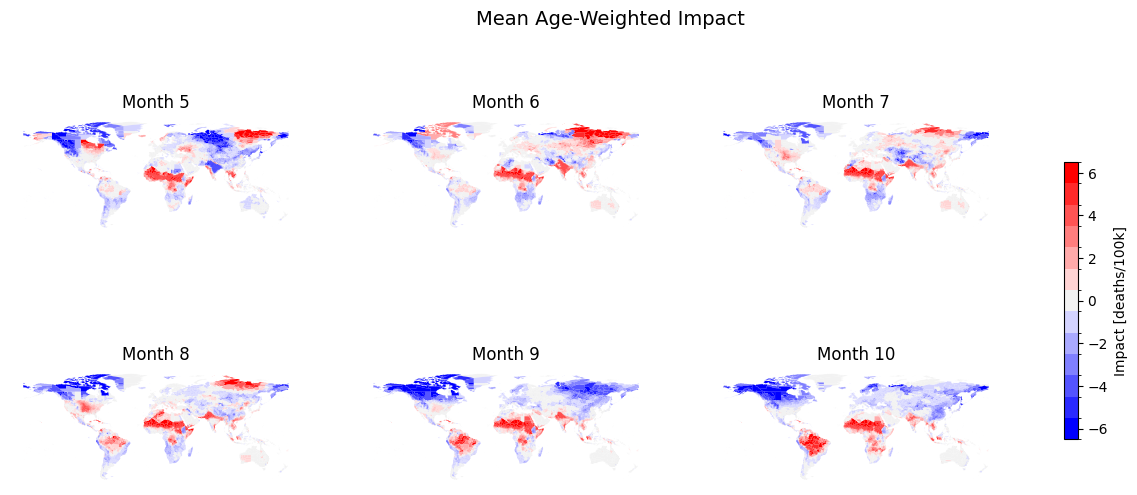

In [10]:
gmfd = True
da = impact_gmfd if gmfd else impact_og
_polygons_num = compute_stats(da, polygon=True)
gdf = _polygons_num

label = 'After' if gmfd else 'Before'
label_s = 'gmfd' if gmfd else 'og'

fig = analysis_utils.plot_monthly(
    gdf,
    col='mean',
    rate=True,
    sup_title=f"Mean Age-Weighted Impact",
    save_title=f'{label_s}_mean_rate_agwt.png',
    cm='bwr',
)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


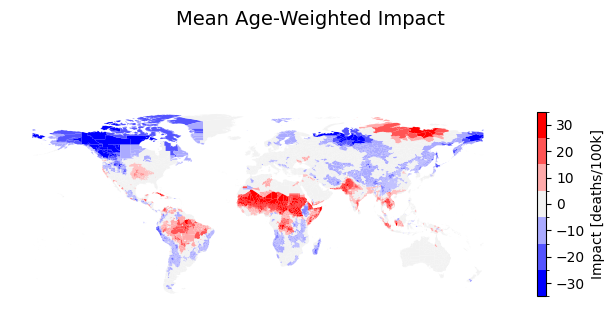

In [11]:
gmfd = True
da = impact_gmfd if gmfd else impact_og
_polygons_num = compute_stats(da, polygon=True)
gdf = _polygons_num

label = 'After' if gmfd else 'Before'
label_s = 'gmfd' if gmfd else 'og'

fig = analysis_utils.plot_cumulative(
    gdf,
    col='mean',
    rate=True,
    sup_title=f"Mean Age-Weighted Impact",
    save_title=f'{label_s}_mean_rate_agwt.png',
    cm='bwr',
)

## Change in Impact (w/ GMFD)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


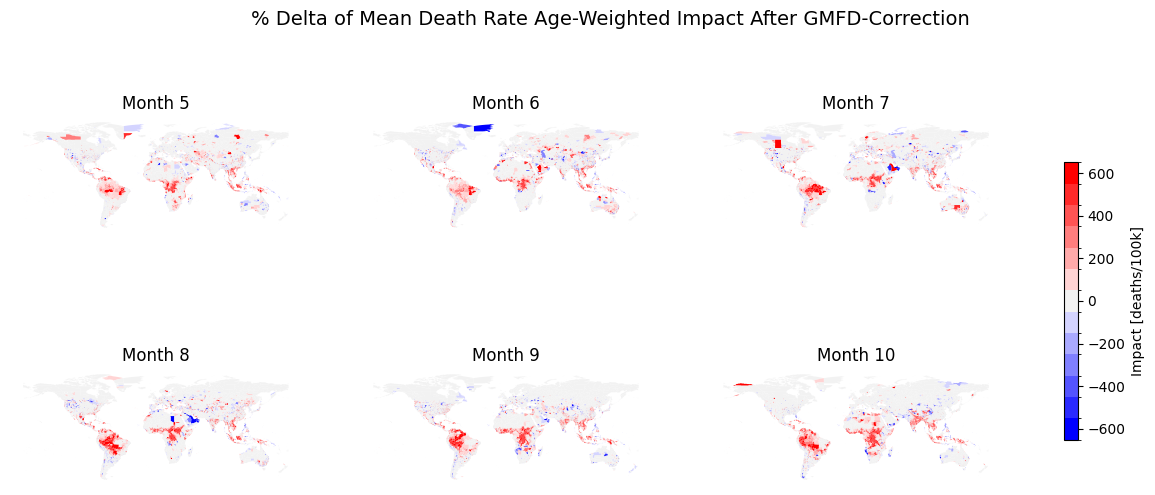

In [13]:
rate = True
pct_change = True

if pct_change:
    diff = 100*(impact_gmfd-impact_og)/np.abs(impact_og)
else:
    diff = (impact_gmfd-impact_og)
_polygons_num = compute_stats(diff, polygon = True)   
gdf = _polygons_num

metric = "% Delta" if pct_change else "Delta"
metric_s = "pct_delta" if pct_change else "delta"
units = "[deaths/100k]" if rate else "[num. deaths]"
label = 'Death Rate' if rate else "Deaths"
label_s = 'rate' if rate else "deaths"

sup_title = f'{metric} of Mean {label} Age-Weighted Impact After GMFD-Correction'
save_title = f'{metric_s}_gmfd_mean_{label_s}_agwt.png'

fig = analysis_utils.plot_monthly (gdf, 'mean', rate = True, c_title = "", sup_title = sup_title, save_title = save_title)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


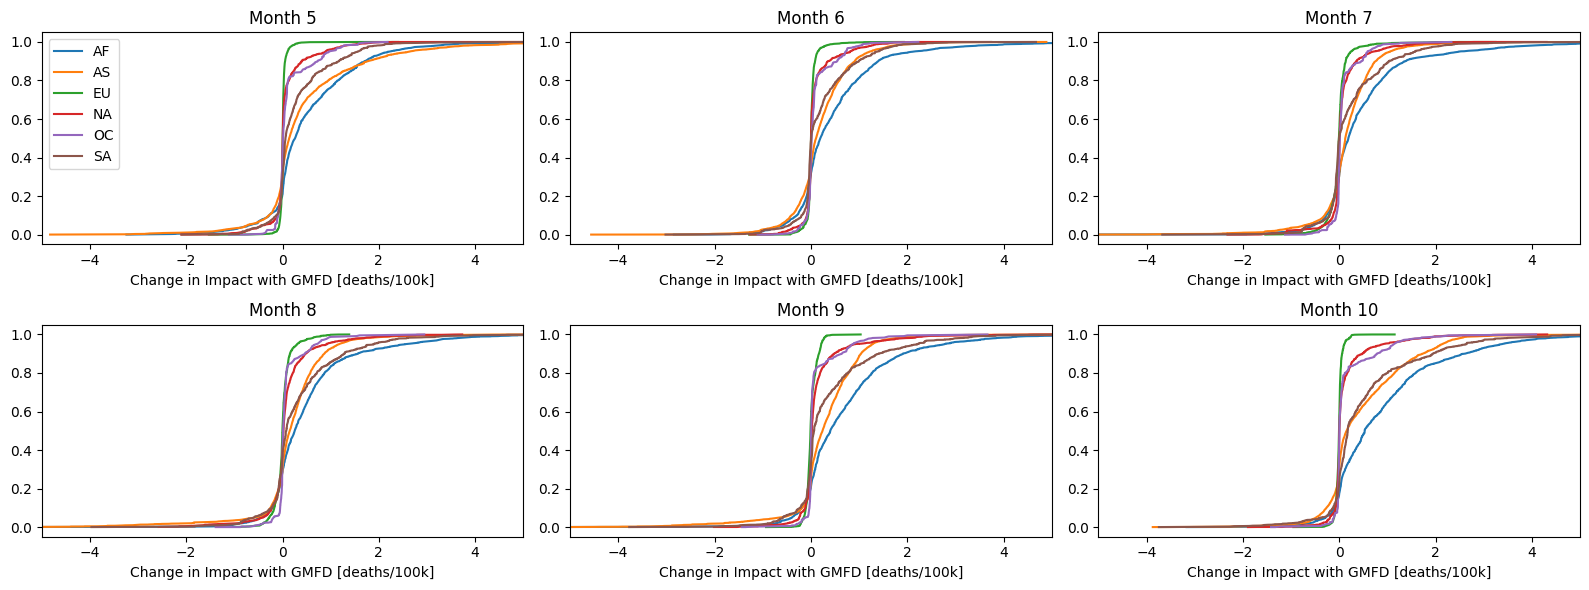

In [16]:
import pycountry_convert as pc
import matplotlib.pyplot as plt

def iso_to_continent(iso3):
    try:
        iso2 = pc.country_alpha3_to_country_alpha2(iso3)
        return pc.country_alpha2_to_continent_code(iso2)
    except:
        return None
rate = True
pct_change = False

if pct_change:
    diff = 100*(impact_gmfd-impact_og)/np.abs(impact_og)
else:
    diff = (impact_gmfd-impact_og)
_polygons_num = compute_stats(diff, polygon = True)   
gdf = _polygons_num

gdf['continent'] = gdf['ISO'].apply(iso_to_continent)

months = sorted(gdf['month'].unique())
fig, axes = plt.subplots(2, 3, figsize=(16, 6))

for ax, month in zip(axes.flat, months):
    monthly = gdf[gdf['month'] == month][['region', 'ISO', 'continent', 'mean']].merge(
        socioeconomics[['region', 'pop']].to_dataframe().reset_index(), on='region'
    )

    for cont, group in monthly.groupby('continent'):
        group = group.sort_values('mean')
        x = group['mean'].values
        w = group['pop'].values
        y = np.cumsum(w) / np.sum(w)
        ax.plot(x, y, label=cont)

    ax.set_title(f'Month {month}')
    ax.set_xlabel('Change in Impact with GMFD [deaths/100k]')
    ax.set_xlim(-5, 5)

for ax in axes.flat[len(months):]:
    ax.set_axis_off()

axes.flat[0].legend()
fig.tight_layout()

## Sign Differences: Likelihood of Impact

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


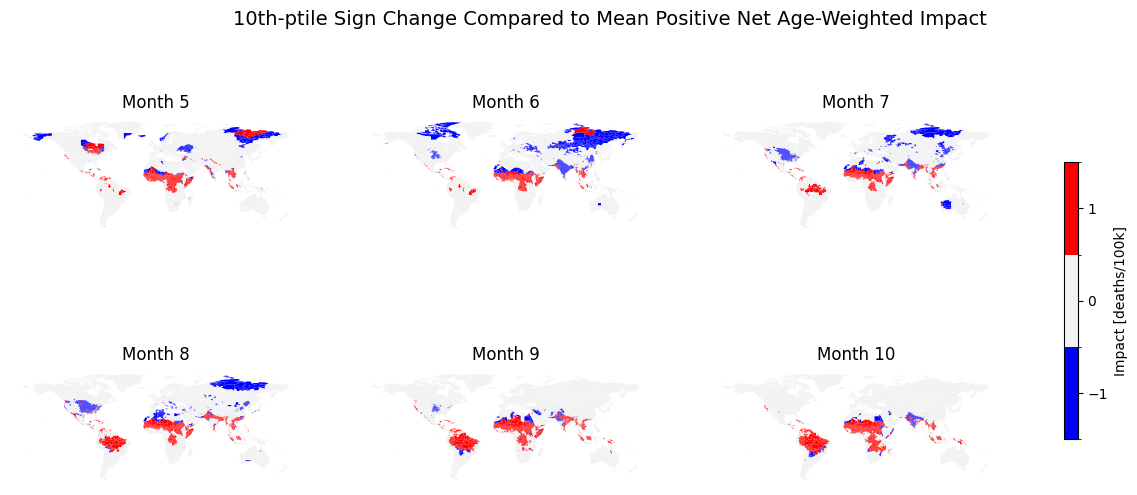

In [17]:
impact_dir_neg = False

da_impact = impact_gmfd
_polygons_num = compute_stats(da_impact, polygon=True)
gdf = _polygons_num

if impact_dir_neg:
    gdf['sign_diff'] = np.sign(gdf['mean']) * np.sign(gdf['p90']) * (gdf['mean'] < -1)
    cm = 'bwr_r'
else:
    gdf['sign_diff'] = np.sign(gdf['mean']) * np.sign(gdf['p10']) * (gdf['mean'] > 1)
    cm = 'bwr'

units = "deaths/100k" if rate else "num. deaths"

ptile = '90' if impact_dir_neg else '10'
neg = "Negative" if impact_dir_neg else "Positive"

fig = analysis_utils.plot_monthly(
    gdf,
    col='sign_diff',
    rate=rate,
    sup_title=f"{ptile}th-ptile Sign Change Compared to Mean {neg} Net Age-Weighted Impact",
    save_title=f'sign_change_{ptile}ptile_{neg}_mean_net_agwt.png',
    cm=cm,
)

## Temperature Range

In [12]:
#Temperature Anomalies
#Ranges in impacts line up (higher spread in impact, line up with larger spread in forecast)
da_forecast = forecast_gmfd['tas'].groupby('time.month').mean()
da_forecast = compute_stats(da_forecast, polygon = False)
da_impact = impact_gmfd
da_impact = compute_stats(da_impact, polygon = False)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


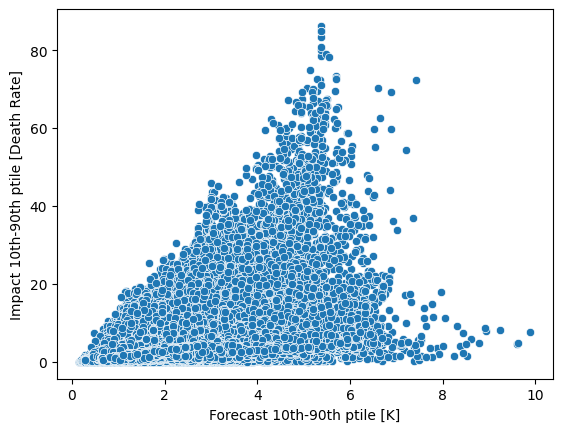

In [19]:
merged = xr.merge([da_impact['range'].rename('Impact_Range'), da_forecast['range'].rename('Forecast_Range')], join='inner')
#merged = xr.merge([da_impact['pct_spread'].rename('Impact'), da_forecast['pct_spread'].rename('Forecast')], join='inner')

mask = (merged['Impact_Range'] > .001).compute()
df = merged.where(mask, drop=True).to_dataframe().reset_index()

import seaborn as sns
sns.scatterplot(data=df, x='Forecast_Range', y='Impact_Range')
#plt.yscale('log')
plt.xlabel('Forecast 10th-90th ptile [K]')
plt.ylabel('Impact 10th-90th ptile [Death Rate]')

plt.savefig(f'impact_rate_tas_scatter_ensemble.png', dpi=600, bbox_inches="tight")


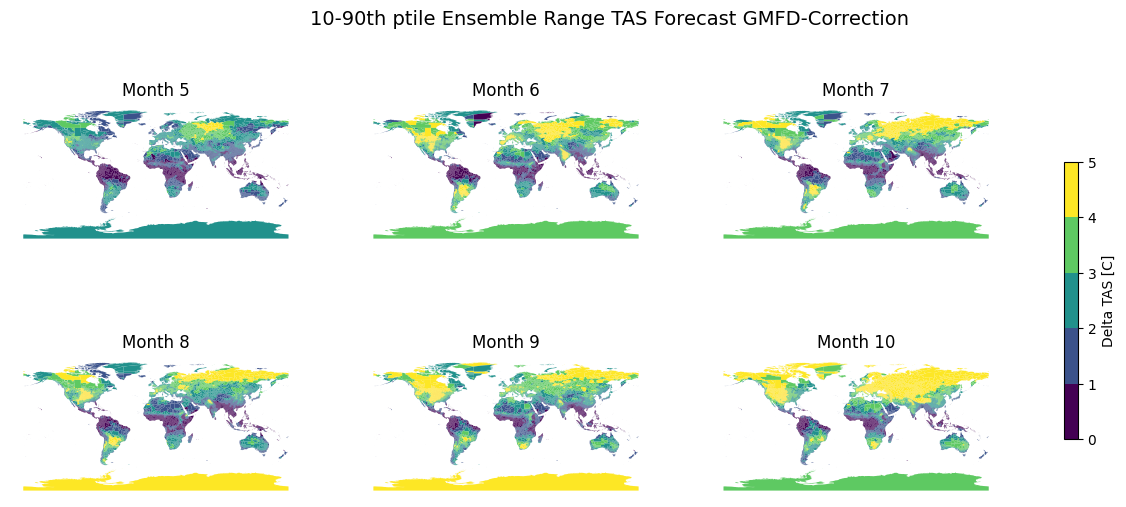

In [26]:
gdf = compute_stats(forecast_gmfd['tas'].groupby('time.month').mean(), polygon=True)
col = 'range'
absmax = gdf[col].abs().quantile(0.95)

fig = analysis_utils.plot_monthly(
    gdf,
    col=col,
    cm='viridis',
    vmin=0,
    vmax=absmax,
    sup_title="10-90th ptile Ensemble Range TAS Forecast GMFD-Correction",
    save_title='range_gmfd_tas_ensemble.png',
    cbar_label='Delta TAS [C]',
)

In [ ]:
gdf = compute_stats(forecast_gmfd['tas'].groupby('time.month').mean(), polygon = True)

# percent of mean (i.e. negative 10)
col = 'range'

absmax = gdf[col].abs().quantile(0.95)
norm = plt.Normalize(vmin=0, vmax=absmax)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
months = sorted(gdf['month'].unique())

fig, axes = plt.subplots(2, 3, figsize=(16, 6))

for ax, month in zip(axes.flat, months):
    group = gdf[gdf['month'] == month]
    group.plot(
        column=col,
        legend=False,
        ax=ax,
        cmap="viridis",
        norm=norm,
        edgecolor='black',
        linewidth=0.03,
    )
    ax.set_title(f'Month {month}')
    ax.set_axis_off()

for ax in axes.flat[len(months):]:
    ax.set_axis_off()

fig.colorbar(sm, ax=axes.ravel().tolist(), location='right', shrink=0.6, label = 'Delta TAS [C]')

fig.suptitle(f"10-90th ptile Ensemble Range TAS Forecast GMFD-Correction", fontsize=14)
fig.savefig(f'range_gmfd_tas_ensemble.png', dpi=600, bbox_inches="tight")

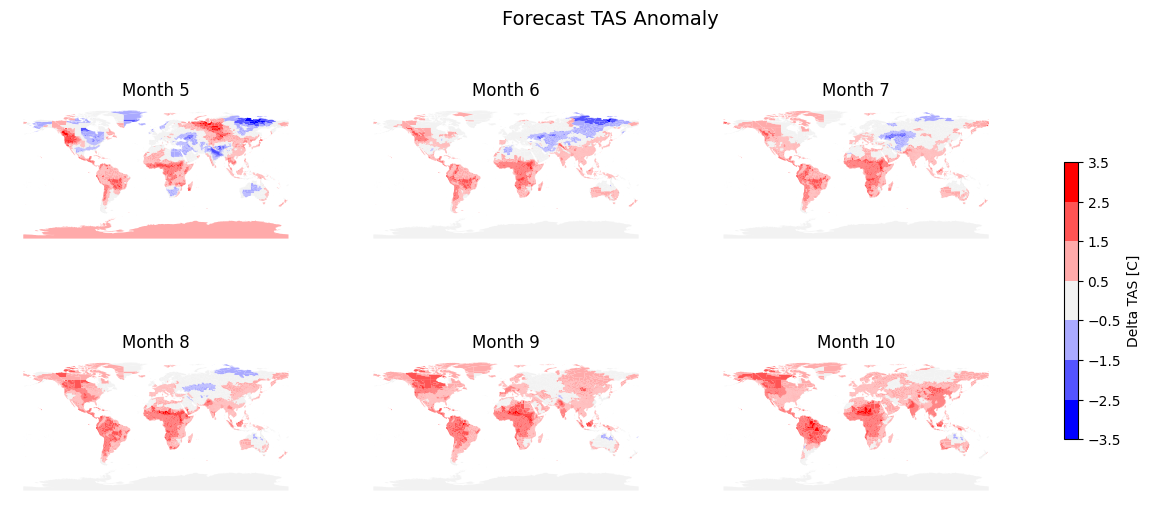

In [13]:
anomaly = forecast_gmfd['tas'].groupby('time.month').mean() - reanlysis_gmfd['tas'].groupby('time.month').mean()
gdf = compute_stats(anomaly, polygon=True)

fig = analysis_utils.plot_monthly(
    gdf,
    col='mean',
    cm='bwr',
    cbar_label='Delta TAS [C]',
    sup_title="Forecast TAS Anomaly",
    save_title='tas_anomaly.png',
)